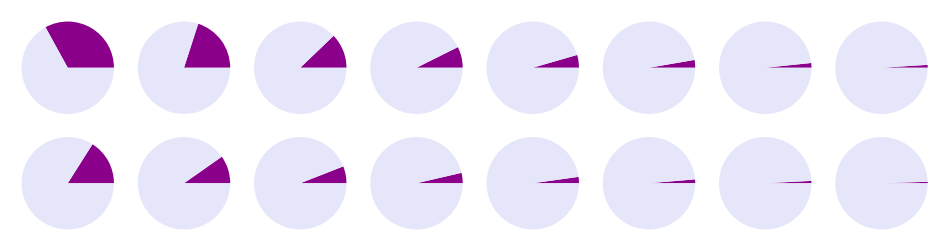

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the proportions for the purple slices
# We use np.logspace to create a sequence of numbers that decrease logarithmically,
# which matches the visual effect in the image.

# Proportions for the top row of pie charts (e.g., from ~33% down to 1%)
proportions_top = [1024/(1024+1211), ]

# Proportions for the bottom row (e.g., from ~16% down to 0.5%)
proportions_bottom = [1024/(1024+1211), ]

# Combine all proportions into a single list
all_proportions = np.concatenate([proportions_top, proportions_bottom])


# 2. Define the colors for the pie slices
# A dark magenta and a light lavender to match the image
colors = ['#8B008B', '#E6E6FA']


# 3. Create the figure and subplot grid
# This creates a 2x8 grid of plots. We set the overall figure size and background color.
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
fig.patch.set_facecolor('white')


# 4. Iterate through each subplot (axis) and plot the pie chart
for ax, proportion in zip(axes.flat, all_proportions):
    # The data for each pie chart consists of the purple slice's proportion
    # and the remaining proportion for the lavender slice.
    data = [proportion, 1 - proportion]
    
    # Plot the pie chart on the current axis
    # 'startangle=0' begins the first slice on the horizontal axis.
    # We remove the white border between wedges for a cleaner look.
    ax.pie(data, colors=colors, startangle=0, wedgeprops={'edgecolor': 'none'})
    
    # Turn off the axis lines and labels
    ax.axis('off')


# 5. Adjust the layout to minimize empty space and display the plot
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

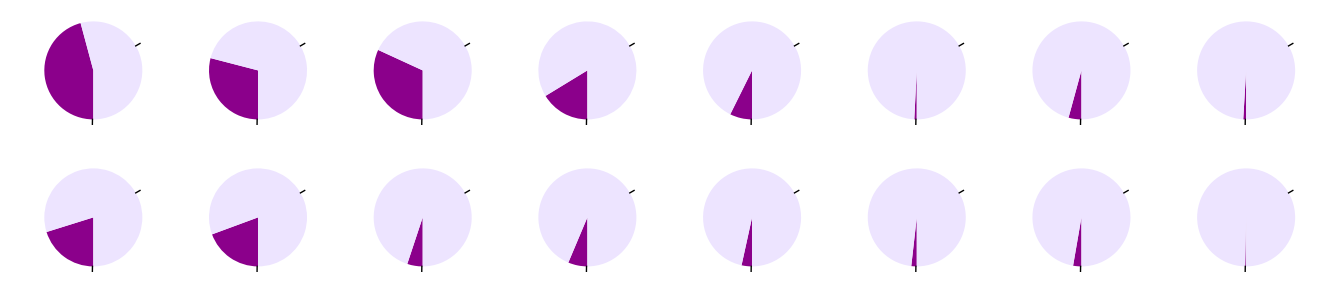

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the proportions for the purple slices
proportions_top = [1024/(1024+1211), 649/(649+1586), 712/(712+1523), 364/(364+1871), 
                164/(164+2071), 18/(18+2217), 95/(95+2140), 21/(21+2214)] 
proportions_bottom = [
        451/(451+1784), 433/(433+1802), 119/(2216+119), 142/(142+2093),
        77/(77+2158), 40/(40+2195), 61/(60+2174), 7/(7+2228)
]
# We combine them into one list to apply the same logic to all charts
all_proportions = np.concatenate([proportions_top, proportions_bottom])

# 2. Define the colors for the pie slices
colors = ["#8B008B",'#EDE4FF']

# 3. Create the figure and subplot grid
fig, axes = plt.subplots(2, 8, figsize=(17, 3.5))
fig.patch.set_facecolor('white')


# 4. Loop through ALL subplots and apply the same unified logic
for ax, proportion in zip(axes.flat, all_proportions):
    # Set the start angle to 270 degrees (bottom-middle)
    start_angle = 270
    
    # Plot the pie chart with two key changes:
    #   - startangle=270 (starts at the bottom)
    #   - counterclock=False (draws the slice clockwise, to the left)
    data = [proportion, 1 - proportion]
    ax.pie(data, colors=colors, startangle=start_angle, counterclock=False, wedgeprops={'edgecolor': 'none'})
    ax.axis('off')
    
    # --- Add the Text Label ---
    # Calculate the angle for the middle of the slice (moving clockwise)
    slice_angle_deg = proportion * 360
    mid_angle_deg = start_angle - (slice_angle_deg / 2) # Subtract to account for clockwise direction
    
    # Convert angle to radians for positioning
    mid_angle_rad = np.deg2rad(mid_angle_deg)
    
    # Set the text position just outside the pie's radius
    text_radius = 1.4
    x = text_radius * np.cos(mid_angle_rad)
    y = text_radius * np.sin(mid_angle_rad)
    
    # Format the proportion as a percentage string
    label_text = f'{proportion:.1%}'
    
    # Add the text to the plot
    ax.text(x, y, label_text,
            ha='center',
            va='center',
            color='white',
            fontsize=7)

    # --- NEW: Add Fixed Ticks ---
    # Define the angles where you want ticks
    tick_angles_deg = [269, 30]
    
    for angle_deg in tick_angles_deg:
        angle_rad = np.deg2rad(angle_deg)
        
        # Define the start and end radius for the tick line
        # This makes the tick cross the pie's border.
        r_start = 1.0
        r_end = 1.1
        
        # Calculate start and end points of the tick line
        x_points = [r_start * np.cos(angle_rad), r_end * np.cos(angle_rad)]
        y_points = [r_start * np.sin(angle_rad), r_end * np.sin(angle_rad)]
        
        # Plot the tick line on the chart
        ax.plot(x_points, y_points, color='black', linewidth=1)



# 5. Adjust the layout and display the final plot
plt.subplots_adjust(wspace=0, hspace=0.2)
plt.savefig('Fig4_PIE_results.pdf',bbox_inches = "tight",transparent=True)
